# Regression Models Using Gradient Descent

## Goals

In this Assignment:

 - You will implement Linear, Quadratic and Cubic Regression models using **Gradient Descent** instead of solving simultaneous equations / normal equation.
 - You will implement Gradient Descent from scratch (no sklearn) using NumPy, in a vectorized way (no for-loop over training examples — a for-loop over iterations/epochs is fine, since Gradient Descent is inherently iterative).

## Tools
In this lab we will make use of:
- NumPy, a popular library for scientific computing
- Matplotlib, a popular library for plotting data
- Pandas, a Python library for data analysis

### Import Libraries

![Libraries](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Libraries.png?raw=true)


In [2]:
#Your code Here
#import the necessary libraries (numpy, pandas, matplotlib.pyplot)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

###  Fetch Data From CSV Files

![Load Data](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Load%20N%20show.png?raw=true)

In [3]:
#Your code Here
#Read the training and testing data from the file
trainData = pd.read_csv('trainRegression.csv')
testData = pd.read_csv('testRegression.csv')

TrD = trainData.head()
TsD = testData.head()

### Show Data

In [4]:
#Your code Here
#Show the first 5 rows of the training data

print(TrD)
print()
print(TsD)

      X       R
0  0.01 -0.2730
1  0.02 -0.1170
2  0.03 -0.3090
3  0.04  0.0306
4  0.05 -0.0802

     X      R
0  0.0 -0.226
1  0.1 -0.174
2  0.2  0.459
3  0.3  0.638
4  0.4  0.869


##### Expected Output


![Output 1](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/O1.png?raw=true)


### Type Casting of Data

![TypeCasting](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Type%20Casting.png?raw=true)


In [5]:
#Your code Here
#TypeCast the data (train_x, train_y, test_x, test_y) into numpy arrays

x_train = np.array(trainData['X'])
y_train = np.array(trainData['R'])
x_test = np.array(testData['X'])
y_test = np.array(testData['R'])

### Plot Data

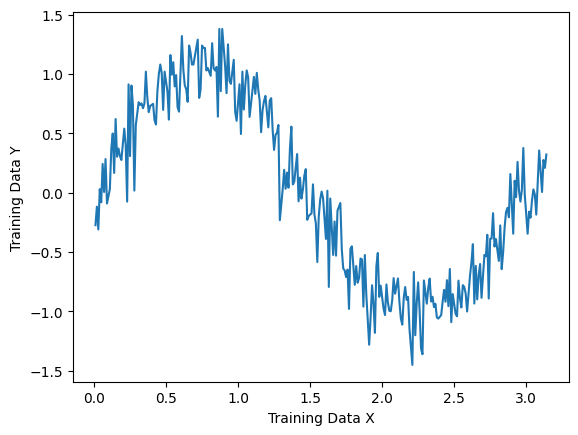

In [6]:
#Your code Here
#Plot your Training Data using matplotlib
plt.plot(x_train, y_train)
plt.xlabel('Training Data X')
plt.ylabel('Training Data Y')
plt.show()

##### Expected Output


![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/O2.png?raw=true)


### Fit Linear Regression Model Using Gradient Descent (Training Data)

 As our linear Model was

![Cost Funtion](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion1.png?raw=true
)

And using derivatives we transformed our model into 2 simultaneous equations

![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20Model%20Eqs.png?raw=true)


Then converted it in matrix form

![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20Model.png?raw=true)


NOTE: Do NOT use a for-loop to compute sums across training examples — vectorize using NumPy (matrix/dot products). A for-loop is only allowed for looping over the number of iterations/epochs.

HINT:
- Build **X** as an (m x 2) matrix: first column of ones (for θ0), second column = x
- Represent **θ** as a (2 x 1) vector: [θ0, θ1]
- Predictions: **h = X @ θ**
- Gradient: **grad = (1/m) * X.T @ (h − y)**
- Update: **θ = θ − α * grad**

In [17]:
#Your code Here
#Step 1: Build the X matrix (bias column of ones + x column)
#Step 2: Initialize theta (zeros), learning rate (alpha) and number of iterations
#Step 3: Run the Gradient Descent loop (for-loop over iterations ONLY):
#         - compute predictions h = X @ theta
#         - compute gradient = (1/m) * X.T @ (h - y)
#         - update theta = theta - alpha * gradient
#         - (optional) store the cost at every iteration in a list for plotting later

X = np.column_stack((np.ones(len(x_train)), x_train))
theta = np.zeros(2)
alpha = 0.01
iterations = 1000
m = len(x_train)
cost_history = []

for i in range(iterations):
  h = X @ theta
  error = h - y_train
  gradient = (1/m) * X.T @ (error)
  theta = theta - alpha * gradient
  cost = (1 / (2 * m)) * np.sum((h - y_train) ** 2)
  cost_history.append(cost)

In [18]:
theta

array([ 0.75118535, -0.49031509])

#### Plot Cost vs Iterations (Convergence Check)

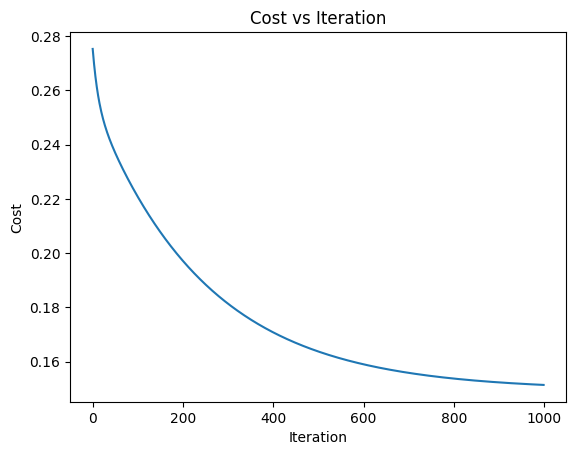

In [19]:
#Your code Here
#Plot the cost history you stored above against the iteration number
#This plot should show the cost decreasing and flattening out as Gradient Descent converges

plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.show()

#### Print Final Values of θ0 and θ1

In [20]:
#Your code Here
#Print the final learned values of theta (theta0, theta1)

print("Theta0:", theta[0])
print("Theta1:", theta[1])

Theta0: 0.7511853468655251
Theta1: -0.4903150916429282


### Run Predictions (Testing Data)

In [21]:
# Your code Here
# Build the test X matrix the same way (bias column of ones + test_x column)
# Use the formula: predictions = X_test @ theta
# _____DO NOT USE FOR LOOP_____

X_test = np.column_stack((np.ones(len(x_test)), x_test))
predictions = X_test @ theta

### Mean Square Error

![Cost Funtion](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion1.png?raw=true
)

In [ ]:
#Your code Here
#Using the cost function, calculate the MSE of the model on the test data

m = len(y_test)

mse = (1 / (2 * m)) * np.sum((predictions - y_test) ** 2)

print("MSE:", mse)

### Plot Data (Train and Test Data)

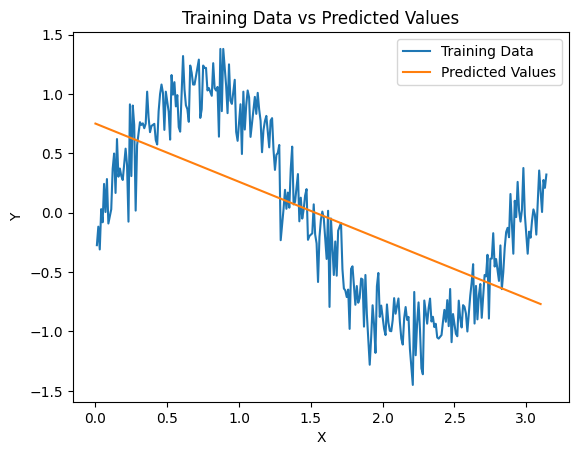

In [24]:
##Your code Here
#Plot the predicted values of y against the test_x (and overlay on training data)

plt.plot(x_train, y_train, label='Training Data')
plt.plot(x_test, predictions, label='Predicted Values')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Training Data vs Predicted Values')
plt.legend()
plt.show()

## Now Fit The Quadratic Model Using Gradient Descent

Our quadratic model is:

**h(x) = θ0 + θ1 * x + θ2 * x²**

The same Gradient Descent approach applies — only the feature matrix **X** changes.

HINT:
- Build **X** as an (m x 3) matrix: [1, x, x²]
- **θ** is now a (3 x 1) vector: [θ0, θ1, θ2]
- Predictions: **h = X @ θ**
- Gradient: **grad = (1/m) * X.T @ (h − y)**
- Update: **θ = θ − α * grad** (repeat for the chosen number of iterations)

NOTE: You may need to standardize/normalize x (and x²) before running Gradient Descent so it converges — large values of x² can make Gradient Descent diverge or converge very slowly with a normal learning rate.

In [25]:
#Your code Here
#For loop is NOT recommended for computing sums across training examples,
#use numpy functions/matrix operations for that.
#A for-loop over the number of iterations IS required for Gradient Descent.
#Steps:
# 1. Build X = [1, x, x^2]  (consider normalizing x, x^2 first)
# 2. Initialize theta (zeros of shape (3,1)), alpha, iterations
# 3. Run Gradient Descent loop, storing cost history

X_quad = np.column_stack((np.ones(len(x_train)), x_train, x_train**2))

theta_quad = np.zeros((3, 1))
alpha = 0.01
iterations = 1000
m = len(y_train)

y_train_col = y_train.reshape(-1, 1)

cost_history_quad = []

for i in range(iterations):
    h = X_quad @ theta_quad

    grad = (1 / m) * X_quad.T @ (h - y_train_col)

    theta_quad = theta_quad - alpha * grad

    cost = (1 / (2 * m)) * np.sum((h - y_train_col) ** 2)
    cost_history_quad.append(cost)

#### Plot Cost vs Iterations (Convergence Check)

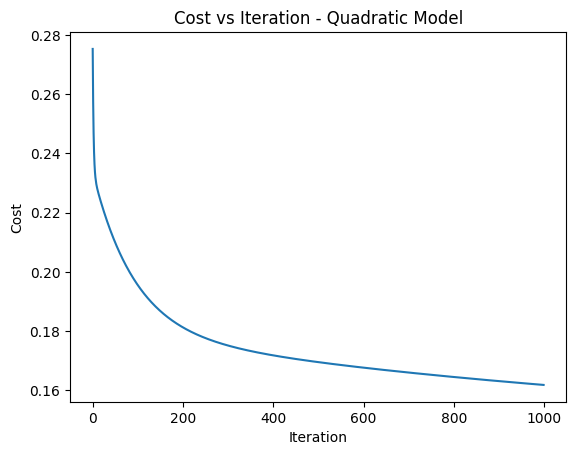

In [26]:
#Your code Here
#Plot the cost history against iteration number

plt.plot(cost_history_quad)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration - Quadratic Model')
plt.show()

#### Print Final Values of θ0, θ1 and θ2

In [27]:
#Your code Here
#Print the final learned values of theta

print("Theta0:", theta_quad[0])
print("Theta1:", theta_quad[1])
print("Theta2:", theta_quad[2])

Theta0: [0.5816842]
Theta1: [-0.17500504]
Theta2: [-0.09735626]


### Run Predictions (Testing data)

In [28]:
# Your code Here
# Build the test X matrix the same way [1, test_x, test_x^2] (apply the SAME normalization used on training data)
# predictions = X_test @ theta
# _____DO NOT USE FOR LOOP_____

X_test_quad = np.column_stack((np.ones(len(x_test)), x_test, x_test**2))

predictions_quad = X_test_quad @ theta_quad

### Mean Square Error

In [29]:
#Your code Here
#Using the cost function calculate the MSE of the model

m = len(y_test)

mse_quad = (1 / (2 * m)) * np.sum((predictions_quad - y_test.reshape(-1, 1)) ** 2)

print("MSE:", mse_quad)

MSE: 0.16100892434420727


### Plot Data (Train and Test Data)

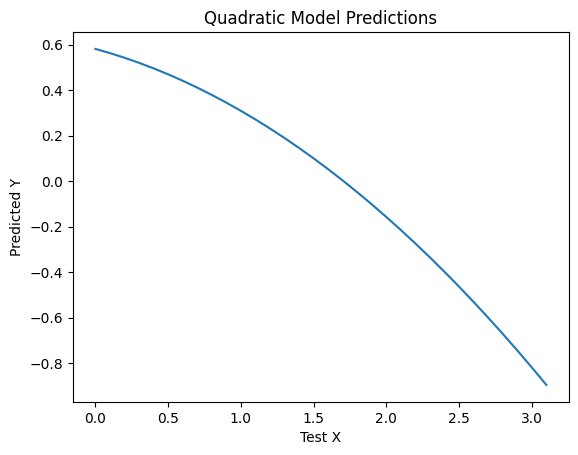

In [32]:
##Your code Here
#Plot the predicted values of y against the test_x

plt.plot(x_test, predictions_quad)

plt.xlabel('Test X')
plt.ylabel('Predicted Y')
plt.title('Quadratic Model Predictions')
plt.show()

## Now Fit The Cubic Model Using Gradient Descent

**h(x) = θ0 + θ1 * x + θ2 * x² + θ3 * x³**

NOTE: Same as before — you are required to compute everything without a for-loop over training data (only the iteration loop for Gradient Descent is allowed).
- HINT: Build X = [1, x, x², x³] (normalize each polynomial feature column before running Gradient Descent)

In [33]:
#Your code Here
#Build X = [1, x, x^2, x^3] (normalize features), initialize theta (zeros of shape (4,1)),
#choose alpha and iterations, then run the Gradient Descent loop storing cost history.

x1 = x_train
x2 = x_train ** 2
x3 = x_train ** 3

x1_norm = (x1 - np.mean(x1)) / np.std(x1)
x2_norm = (x2 - np.mean(x2)) / np.std(x2)
x3_norm = (x3 - np.mean(x3)) / np.std(x3)

X_cubic = np.column_stack((
    np.ones(len(x_train)),
    x1_norm,
    x2_norm,
    x3_norm
))

theta_cubic = np.zeros((4, 1))

alpha = 0.01
iterations = 1000
m = len(y_train)

y_train_col = y_train.reshape(-1, 1)

cost_history_cubic = []

for i in range(iterations):
    h = X_cubic @ theta_cubic

    grad = (1 / m) * X_cubic.T @ (h - y_train_col)

    theta_cubic = theta_cubic - alpha * grad

    cost = (1 / (2 * m)) * np.sum((h - y_train_col) ** 2)
    cost_history_cubic.append(cost)

#### Plot Cost vs Iterations (Convergence Check)

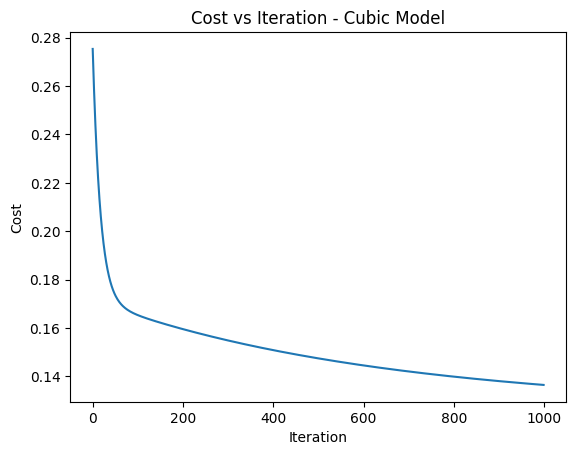

In [34]:
#Your code Here
#Plot the cost history against iteration number

plt.plot(cost_history_cubic)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration - Cubic Model')
plt.show()

#### Print Final Values of the Four θ's

In [35]:
#Your code Here
#Print the final learned values of theta (theta0, theta1, theta2, theta3)

print("Theta0:", theta_cubic[0])
print("Theta1:", theta_cubic[1])
print("Theta2:", theta_cubic[2])
print("Theta3:", theta_cubic[3])

Theta0: [0.00491452]
Theta1: [-0.52152759]
Theta2: [-0.22571338]
Theta3: [0.28390895]


### Run Predictions (Testing data)

In [36]:
# Your code Here
# Build test X the same way [1, test_x, test_x^2, test_x^3] (apply the SAME normalization used on training data)
# predictions = X_test @ theta
# _____DO NOT USE FOR LOOP_____

x1_test = x_test
x2_test = x_test ** 2
x3_test = x_test ** 3

x1_test_norm = (x1_test - np.mean(x_train)) / np.std(x_train)
x2_test_norm = (x2_test - np.mean(x_train ** 2)) / np.std(x_train ** 2)
x3_test_norm = (x3_test - np.mean(x_train ** 3)) / np.std(x_train ** 3)

X_test_cubic = np.column_stack((
    np.ones(len(x_test)),
    x1_test_norm,
    x2_test_norm,
    x3_test_norm
))

predictions_cubic = X_test_cubic @ theta_cubic

### Mean Square Error

In [37]:
#Your code Here
#Using the cost function calculate the MSE of the model

m = len(y_test)

mse_cubic = (1 / (2 * m)) * np.sum(
    (predictions_cubic - y_test.reshape(-1, 1)) ** 2
)

print("MSE:", mse_cubic)

MSE: 0.14854281208459247


### Plot Data (Train and Test Data)

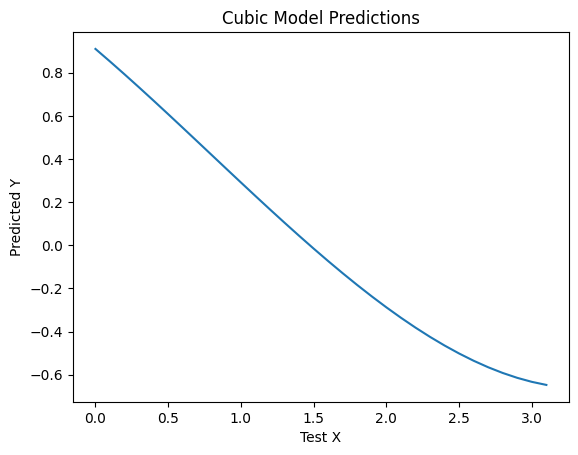

In [38]:
##Your code Here
#Plot the predicted values of y against the test_x

plt.plot(x_test, predictions_cubic)

plt.xlabel('Test X')
plt.ylabel('Predicted Y')
plt.title('Cubic Model Predictions')
plt.show()

### Now You Are Required To Fit Your 4, 5 and 6 Degree Models Step By Step Using Gradient Descent, As You Did Before

## Now Fit The 4 Degree Model

In [39]:
#Your code Here
#Build X = [1, x, x^2, x^3, x^4] (normalized), run Gradient Descent, predict, compute MSE, plot

x1 = x_train
x2 = x_train ** 2
x3 = x_train ** 3
x4 = x_train ** 4

x1_norm = (x1 - np.mean(x1)) / np.std(x1)
x2_norm = (x2 - np.mean(x2)) / np.std(x2)
x3_norm = (x3 - np.mean(x3)) / np.std(x3)
x4_norm = (x4 - np.mean(x4)) / np.std(x4)

X_4 = np.column_stack((
    np.ones(len(x_train)),
    x1_norm,
    x2_norm,
    x3_norm,
    x4_norm
))

theta_4 = np.zeros((5, 1))

alpha = 0.01
iterations = 1000
m = len(y_train)

y_train_col = y_train.reshape(-1, 1)

cost_history_4 = []

for i in range(iterations):
    h = X_4 @ theta_4

    grad = (1 / m) * X_4.T @ (h - y_train_col)

    theta_4 = theta_4 - alpha * grad

    cost = (1 / (2 * m)) * np.sum((h - y_train_col) ** 2)
    cost_history_4.append(cost)

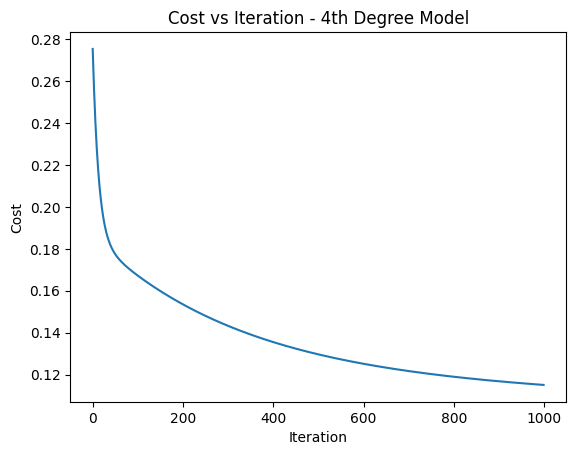

In [40]:
plt.plot(cost_history_4)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration - 4th Degree Model')
plt.show()

In [41]:
print("Theta0:", theta_4[0])
print("Theta1:", theta_4[1])
print("Theta2:", theta_4[2])
print("Theta3:", theta_4[3])
print("Theta4:", theta_4[4])

Theta0: [0.00491452]
Theta1: [-0.54960983]
Theta2: [-0.3793824]
Theta3: [0.04169791]
Theta4: [0.45051774]


In [42]:
x1_test = x_test
x2_test = x_test ** 2
x3_test = x_test ** 3
x4_test = x_test ** 4

x1_test_norm = (x1_test - np.mean(x_train)) / np.std(x_train)
x2_test_norm = (x2_test - np.mean(x_train ** 2)) / np.std(x_train ** 2)
x3_test_norm = (x3_test - np.mean(x_train ** 3)) / np.std(x_train ** 3)
x4_test_norm = (x4_test - np.mean(x_train ** 4)) / np.std(x_train ** 4)

X_test_4 = np.column_stack((
    np.ones(len(x_test)),
    x1_test_norm,
    x2_test_norm,
    x3_test_norm,
    x4_test_norm
))

predictions_4 = X_test_4 @ theta_4

In [43]:
m = len(y_test)

mse_4 = (1 / (2 * m)) * np.sum(
    (predictions_4 - y_test.reshape(-1, 1)) ** 2
)

print("MSE:", mse_4)

MSE: 0.13316060339152858


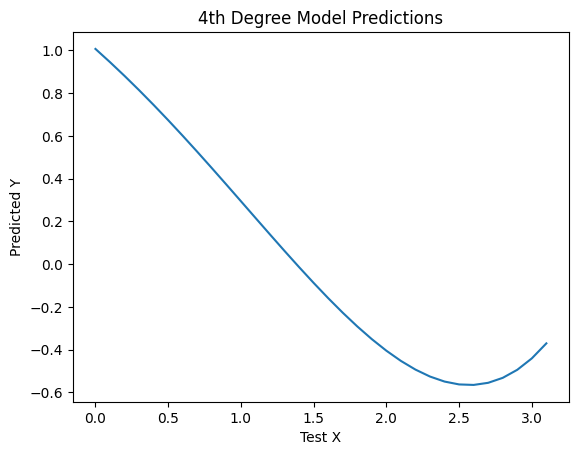

In [44]:
plt.plot(x_test, predictions_4)
plt.xlabel('Test X')
plt.ylabel('Predicted Y')
plt.title('4th Degree Model Predictions')
plt.show()

## Now Fit The 5 Degree Model

In [45]:
#Your code Here
#Build X = [1, x, x^2, x^3, x^4, x^5] (normalized), run Gradient Descent, predict, compute MSE, plot

x1 = x_train
x2 = x_train ** 2
x3 = x_train ** 3
x4 = x_train ** 4
x5 = x_train ** 5

x1_norm = (x1 - np.mean(x1)) / np.std(x1)
x2_norm = (x2 - np.mean(x2)) / np.std(x2)
x3_norm = (x3 - np.mean(x3)) / np.std(x3)
x4_norm = (x4 - np.mean(x4)) / np.std(x4)
x5_norm = (x5 - np.mean(x5)) / np.std(x5)

X_5 = np.column_stack((
    np.ones(len(x_train)),
    x1_norm,
    x2_norm,
    x3_norm,
    x4_norm,
    x5_norm
))

theta_5 = np.zeros((6, 1))

alpha = 0.01
iterations = 1000
m = len(y_train)

y_train_col = y_train.reshape(-1, 1)

cost_history_5 = []

for i in range(iterations):
    h = X_5 @ theta_5

    grad = (1 / m) * X_5.T @ (h - y_train_col)

    theta_5 = theta_5 - alpha * grad

    cost = (1 / (2 * m)) * np.sum((h - y_train_col) ** 2)
    cost_history_5.append(cost)

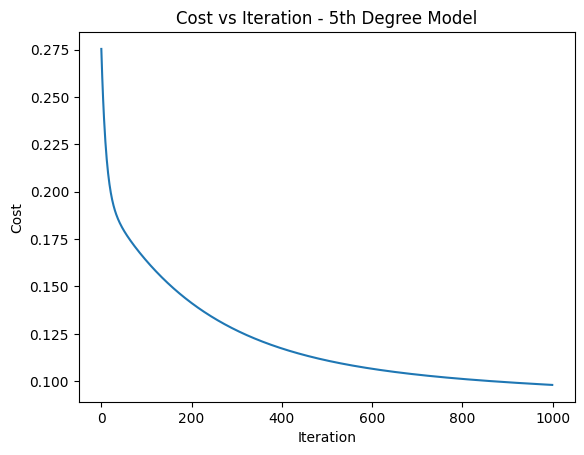

In [46]:
plt.plot(cost_history_5)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration - 5th Degree Model')
plt.show()

In [47]:
print("Theta0:", theta_5[0])
print("Theta1:", theta_5[1])
print("Theta2:", theta_5[2])
print("Theta3:", theta_5[3])
print("Theta4:", theta_5[4])
print("Theta5:", theta_5[5])

Theta0: [0.00491452]
Theta1: [-0.51338926]
Theta2: [-0.4602974]
Theta3: [-0.13250924]
Theta4: [0.20564793]
Theta5: [0.48915164]


In [48]:
x1_test = x_test
x2_test = x_test ** 2
x3_test = x_test ** 3
x4_test = x_test ** 4
x5_test = x_test ** 5

x1_test_norm = (x1_test - np.mean(x_train)) / np.std(x_train)
x2_test_norm = (x2_test - np.mean(x_train ** 2)) / np.std(x_train ** 2)
x3_test_norm = (x3_test - np.mean(x_train ** 3)) / np.std(x_train ** 3)
x4_test_norm = (x4_test - np.mean(x_train ** 4)) / np.std(x_train ** 4)
x5_test_norm = (x5_test - np.mean(x_train ** 5)) / np.std(x_train ** 5)

X_test_5 = np.column_stack((
    np.ones(len(x_test)),
    x1_test_norm,
    x2_test_norm,
    x3_test_norm,
    x4_test_norm,
    x5_test_norm
))

predictions_5 = X_test_5 @ theta_5

In [49]:
m = len(y_test)

mse_5 = (1 / (2 * m)) * np.sum(
    (predictions_5 - y_test.reshape(-1, 1)) ** 2
)

print("MSE:", mse_5)

MSE: 0.11916686509073002


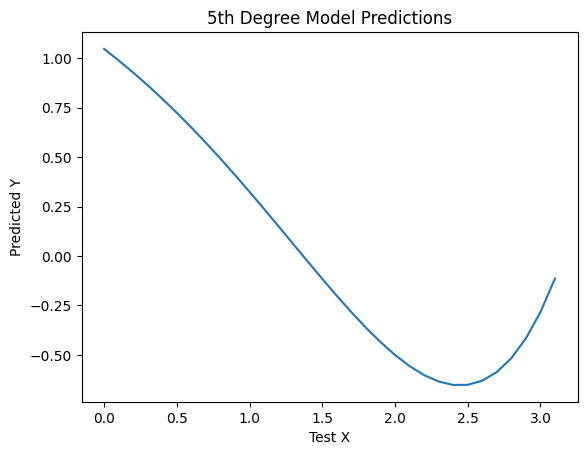

In [50]:
plt.plot(x_test, predictions_5)
plt.xlabel('Test X')
plt.ylabel('Predicted Y')
plt.title('5th Degree Model Predictions')
plt.show()

## Now Fit The 6 Degree Model

In [51]:
#Your code Here
#Build X = [1, x, x^2, ..., x^6] (normalized), run Gradient Descent, predict, compute MSE, plot

x1 = x_train
x2 = x_train ** 2
x3 = x_train ** 3
x4 = x_train ** 4
x5 = x_train ** 5
x6 = x_train ** 6

x1_norm = (x1 - np.mean(x1)) / np.std(x1)
x2_norm = (x2 - np.mean(x2)) / np.std(x2)
x3_norm = (x3 - np.mean(x3)) / np.std(x3)
x4_norm = (x4 - np.mean(x4)) / np.std(x4)
x5_norm = (x5 - np.mean(x5)) / np.std(x5)
x6_norm = (x6 - np.mean(x6)) / np.std(x6)

X_6 = np.column_stack((
    np.ones(len(x_train)),
    x1_norm,
    x2_norm,
    x3_norm,
    x4_norm,
    x5_norm,
    x6_norm
))

theta_6 = np.zeros((7, 1))

alpha = 0.01
iterations = 1000
m = len(y_train)

y_train_col = y_train.reshape(-1, 1)

cost_history_6 = []

for i in range(iterations):
    h = X_6 @ theta_6

    grad = (1 / m) * X_6.T @ (h - y_train_col)

    theta_6 = theta_6 - alpha * grad

    cost = (1 / (2 * m)) * np.sum((h - y_train_col) ** 2)
    cost_history_6.append(cost)

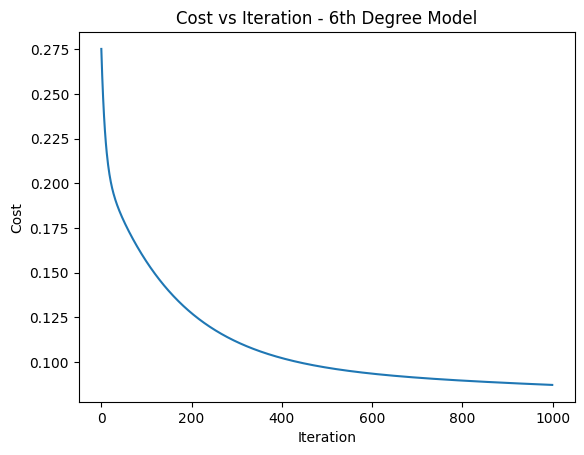

In [52]:
plt.plot(cost_history_6)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration - 6th Degree Model')
plt.show()

In [53]:
print("Theta0:", theta_6[0])
print("Theta1:", theta_6[1])
print("Theta2:", theta_6[2])
print("Theta3:", theta_6[3])
print("Theta4:", theta_6[4])
print("Theta5:", theta_6[5])
print("Theta6:", theta_6[6])

Theta0: [0.00491452]
Theta1: [-0.45381851]
Theta2: [-0.48438097]
Theta3: [-0.23205693]
Theta4: [0.04400696]
Theta5: [0.27770189]
Theta6: [0.4602947]


In [54]:
x1_test = x_test
x2_test = x_test ** 2
x3_test = x_test ** 3
x4_test = x_test ** 4
x5_test = x_test ** 5
x6_test = x_test ** 6

x1_test_norm = (x1_test - np.mean(x_train)) / np.std(x_train)
x2_test_norm = (x2_test - np.mean(x_train ** 2)) / np.std(x_train ** 2)
x3_test_norm = (x3_test - np.mean(x_train ** 3)) / np.std(x_train ** 3)
x4_test_norm = (x4_test - np.mean(x_train ** 4)) / np.std(x_train ** 4)
x5_test_norm = (x5_test - np.mean(x_train ** 5)) / np.std(x_train ** 5)
x6_test_norm = (x6_test - np.mean(x_train ** 6)) / np.std(x_train ** 6)

X_test_6 = np.column_stack((
    np.ones(len(x_test)),
    x1_test_norm,
    x2_test_norm,
    x3_test_norm,
    x4_test_norm,
    x5_test_norm,
    x6_test_norm
))

predictions_6 = X_test_6 @ theta_6

In [55]:
m = len(y_test)

mse_6 = (1 / (2 * m)) * np.sum(
    (predictions_6 - y_test.reshape(-1, 1)) ** 2
)

print("MSE:", mse_6)

MSE: 0.1085938601229477


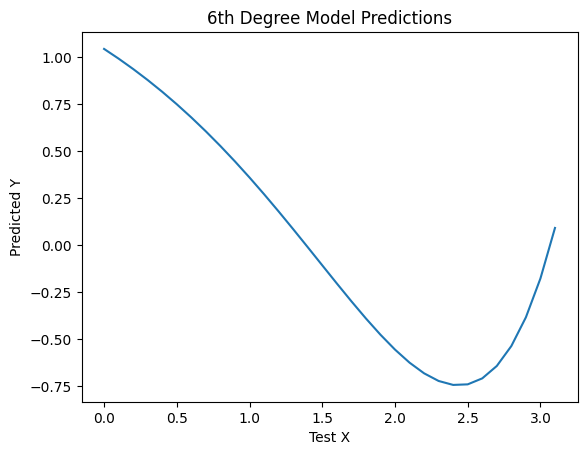

In [56]:
plt.plot(x_test, predictions_6)
plt.xlabel('Test X')
plt.ylabel('Predicted Y')
plt.title('6th Degree Model Predictions')
plt.show()

### Comment on the results by comparing all of your models (train/test MSE, convergence speed, overfitting/underfitting)

MSE values use the (1/2m) convention.

| Model | GD Train MSE | GD Test MSE | Normal Eq. Train MSE | Normal Eq. Test MSE |
|-------|--------------|-------------|----------------------|---------------------|
| 1 (Linear) | 0.1514 | 0.1571 | 0.1496 | 0.1580 |
| 2 (Quadratic) | 0.1619 | 0.1610 | 0.1442 | 0.1630 |
| 3 (Cubic) | 0.1365 | 0.1485 | 0.0249 | 0.0258 |
| 4 | 0.1151 | 0.1332 | 0.0222 | 0.0250 |
| 5 | 0.0980 | 0.1192 | 0.0193 | 0.0221 |
| 6 | 0.0871 | 0.1086 | 0.0193 | 0.0223 |

**Convergence speed.** The linear and quadratic models level off quickly: their cost barely changes between iterations 500 and 1000. The normalised cubic-to-6th models are still falling steadily at iteration 1000 (for example, the 6th-degree cost drops from 0.0968 to 0.0871 over that range), so they have not converged yet. Their GD errors are about five to six times the normal-equation errors, which is a result of the learning rate and iteration count rather than of the models themselves.

**Overfitting and underfitting.** None of the GD models overfit. Train and test error both fall as the degree increases, and the test error is never much higher than the training error. All models are underfit at this stage because they stopped before reaching their minimum. The overfitting seen with the normal equation at degree 6 cannot appear here, since the models have not yet fitted the noise in the training data.

**Takeaway.** For linear and quadratic regression, gradient descent matches the normal equation to within about 0.002. For higher degrees, the normal equation is exact and fast for a small number of features, while gradient descent needs a larger learning rate, more iterations, or both to get close to the closed-form solution.